## Data Collection and Preparation


In [ ]:
import pandas as pd
from pybaseball import statcast, playerid_reverse_lookup
import warnings
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import percentileofscore

pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore")


def collect_data():
    start_date = datetime(2025, 3, 18)
    end_date = datetime(2025, 9, 28)

    dfs = []

    current = start_date
    while current <= end_date:
        next_day = current + timedelta(days=1)

        try:
            print(f"Pulling {current.date()}")
            df_day = statcast(current.strftime("%Y-%m-%d"))

            if df_day is not None and not df_day.empty:
                dfs.append(df_day)

        except Exception as e:
            print(f"Skipped {current.date()} due to error: {e}")

        current = next_day  # 🔑 always move forward

    return pd.concat(dfs, ignore_index=True)


# df = collect_data()
full_df = pd.read_parquet("statcast_data_2025_rs.parquet")
df_bip = full_df[full_df["type"] == "X"]

In [4]:
df = (
    df_bip.rename(columns={"events": "outcome"})[
        ["outcome", "launch_speed", "launch_angle"]
    ]
    .dropna()
    .reset_index(drop=True)
)
df

,outcome,launch_speed,launch_angle
0,field_out,88.3,70.0
1,double,78.2,53.0
2,field_out,88.2,36.0
3,field_out,98.3,-13.0
4,field_out,72.2,57.0
...,...,...,...
126802,home_run,111.0,27.0
126803,field_out,94.7,2.0
126804,force_out,93.8,-11.0
126805,single,100.8,1.0


In [5]:
df["outcome"].value_counts()

outcome
field_out                    75330
single                       26563
double                        7903
home_run                      5757
force_out                     3423
grounded_into_double_play     3171
sac_fly                       1312
field_error                   1028
triple                         642
sac_bunt                       557
double_play                    387
fielders_choice                386
fielders_choice_out            328
sac_fly_double_play             17
triple_play                      3
Name: count, dtype: int64

In [6]:
df = df[df["outcome"] != "sac_bunt"]
hit_types = ["single", "double", "triple", "home_run"]
df["outcome"] = (
    df["outcome"].where(df["outcome"].isin(hit_types), "out").str.replace("_", " ")
)
print(df["outcome"].value_counts())
df

outcome
out         85385
single      26563
double       7903
home run     5757
triple        642
Name: count, dtype: int64


,outcome,launch_speed,launch_angle
0,out,88.3,70.0
1,double,78.2,53.0
2,out,88.2,36.0
3,out,98.3,-13.0
4,out,72.2,57.0
...,...,...,...
126802,home run,111.0,27.0
126803,out,94.7,2.0
126804,out,93.8,-11.0
126805,single,100.8,1.0


In [7]:
order = ["out", "single", "double", "triple", "home run"]
rank = {v: i for i, v in enumerate(order)}

# reorder for plotting, so out comes first, then hits in order
df = df.iloc[df["outcome"].map(rank).argsort()].reset_index(drop=True)

run_values = {
    "out": 0,
    "single": 0.882,
    "double": 1.254,
    "triple": 1.584,
    "home run": 2.037,
}
df["run_value"] = df["outcome"].map(run_values)
df

,outcome,launch_speed,launch_angle,run_value
0,out,88.3,70.0,0.000
1,out,84.3,68.0,0.000
2,out,68.6,-8.0,0.000
3,out,97.4,31.0,0.000
4,out,66.2,19.0,0.000
...,...,...,...,...
126245,home run,101.7,27.0,2.037
126246,home run,95.3,33.0,2.037
126247,home run,99.7,29.0,2.037
126248,home run,105.2,24.0,2.037


## Plots


<Axes: xlabel='launch_speed', ylabel='launch_angle'>

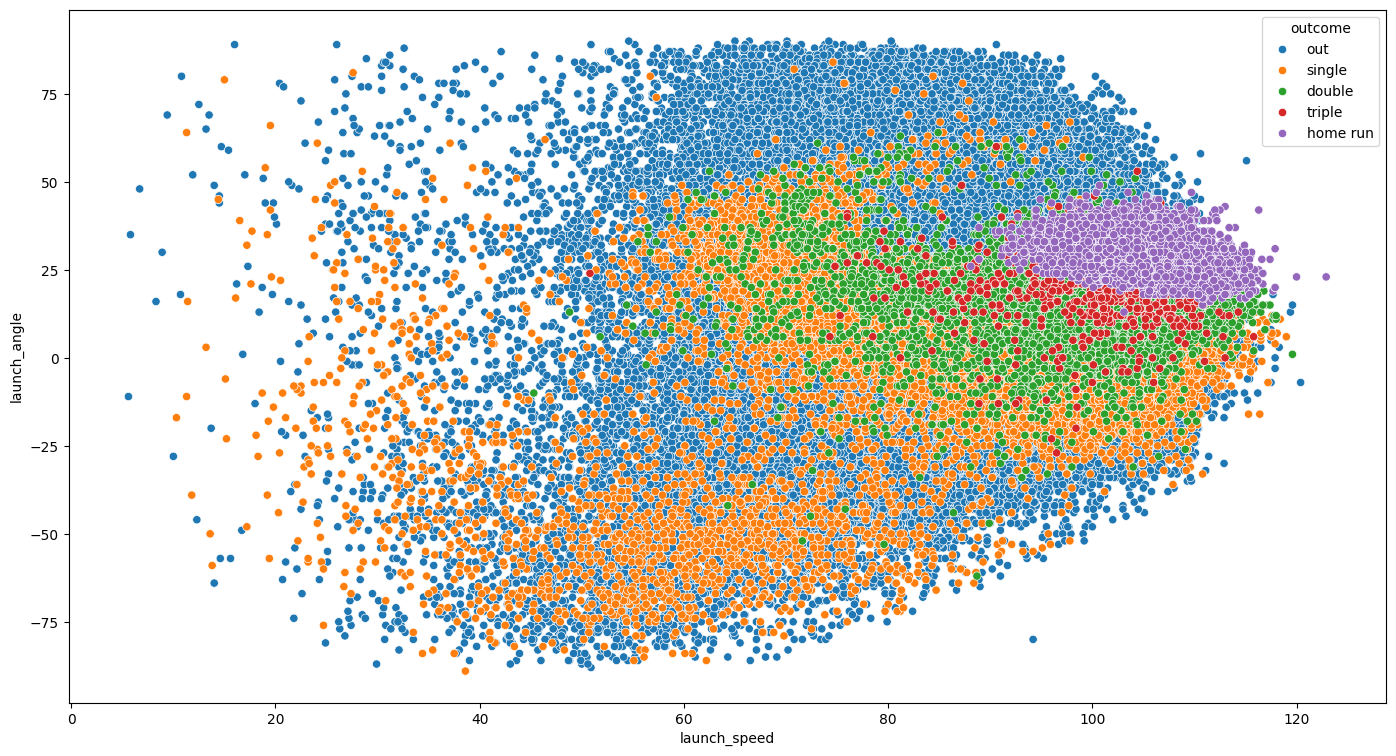

In [8]:
plt.figure(figsize=(17, 9))
sns.scatterplot(df, x="launch_speed", y="launch_angle", hue="outcome", alpha=1)

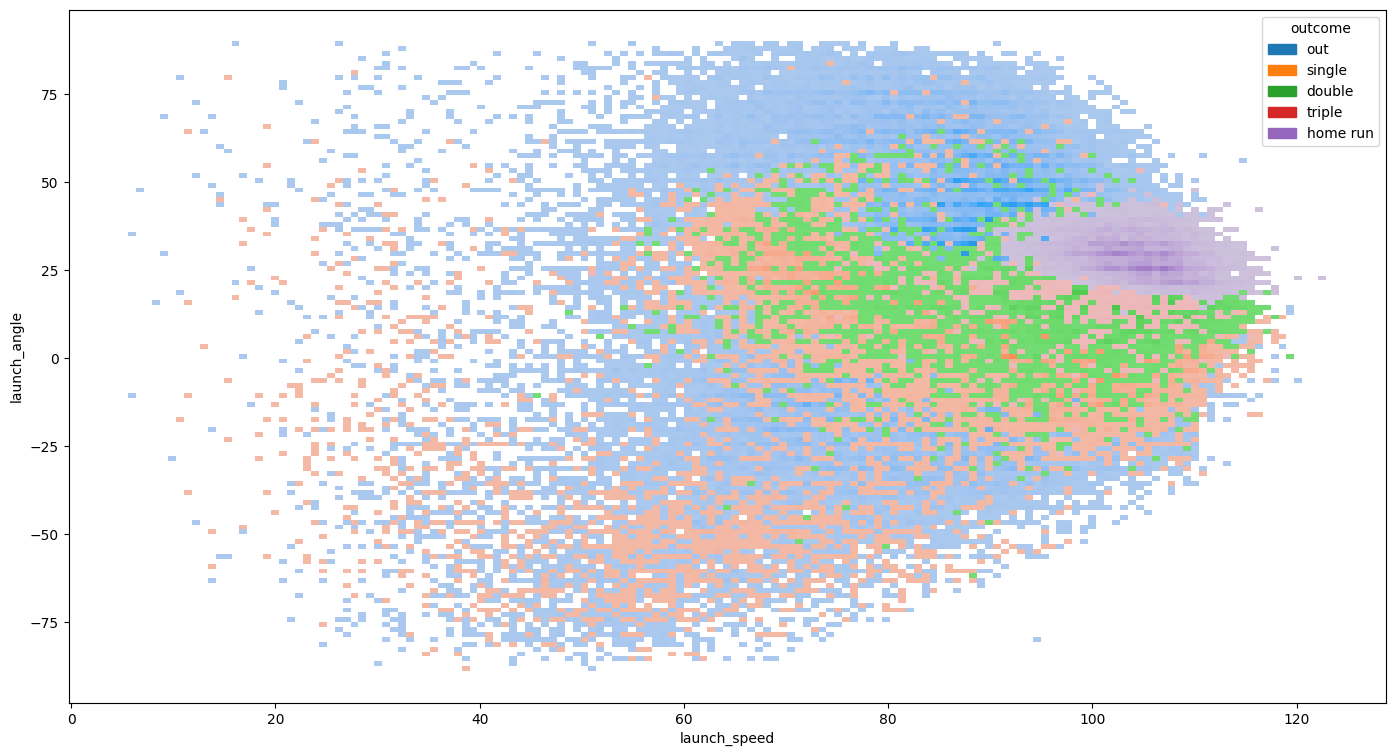

In [9]:
fig = plt.figure(figsize=(17, 9))
sns.histplot(df, x="launch_speed", y="launch_angle", hue="outcome")
fig.savefig("plots/outcomes_2d_hist.png", dpi=300, bbox_inches="tight")

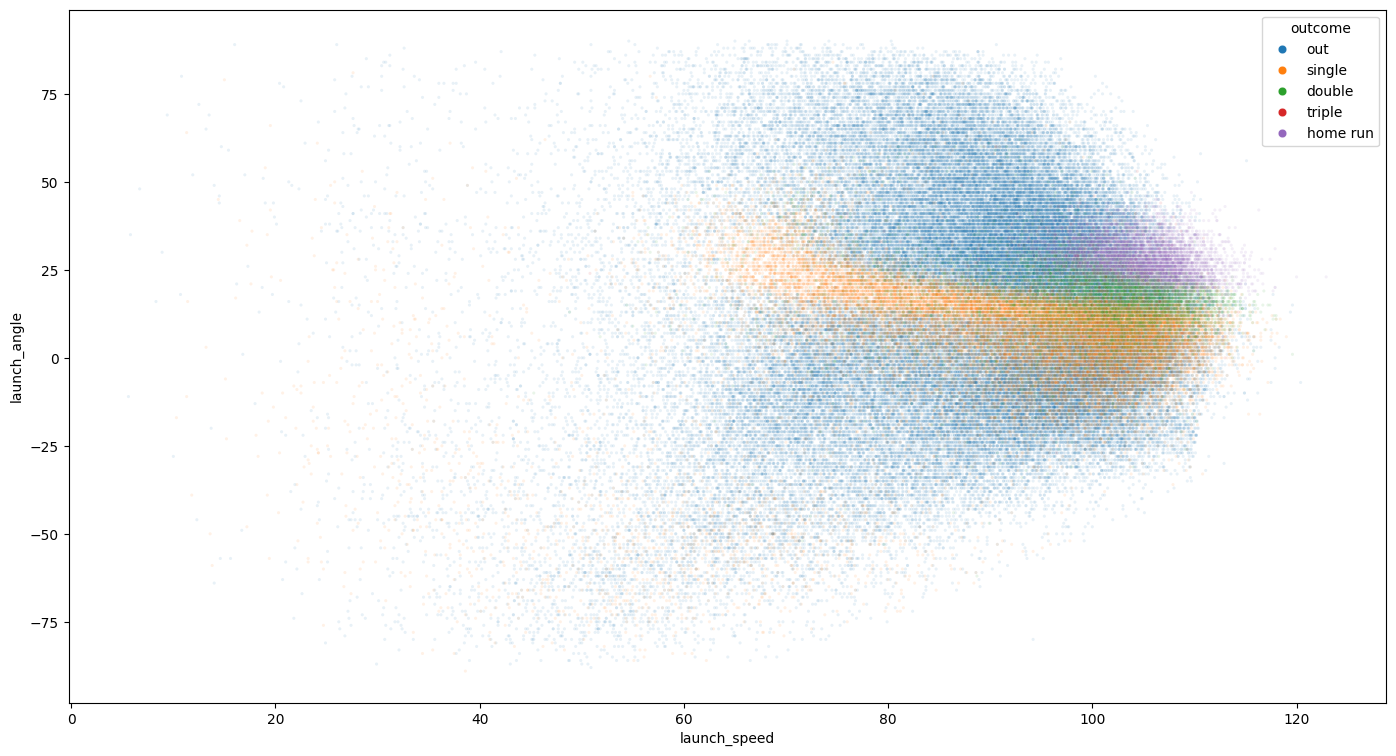

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(17, 9))
ax = sns.scatterplot(
    data=df, x="launch_speed", y="launch_angle", hue="outcome", alpha=0.1, s=5
)

# Override legend marker sizes
for handle in ax.legend_.legend_handles:
    handle.set_markersize(6)
    handle.set_alpha(1.0)
fig.savefig("plots/outcomes_scatter.png", dpi=300, bbox_inches="tight")

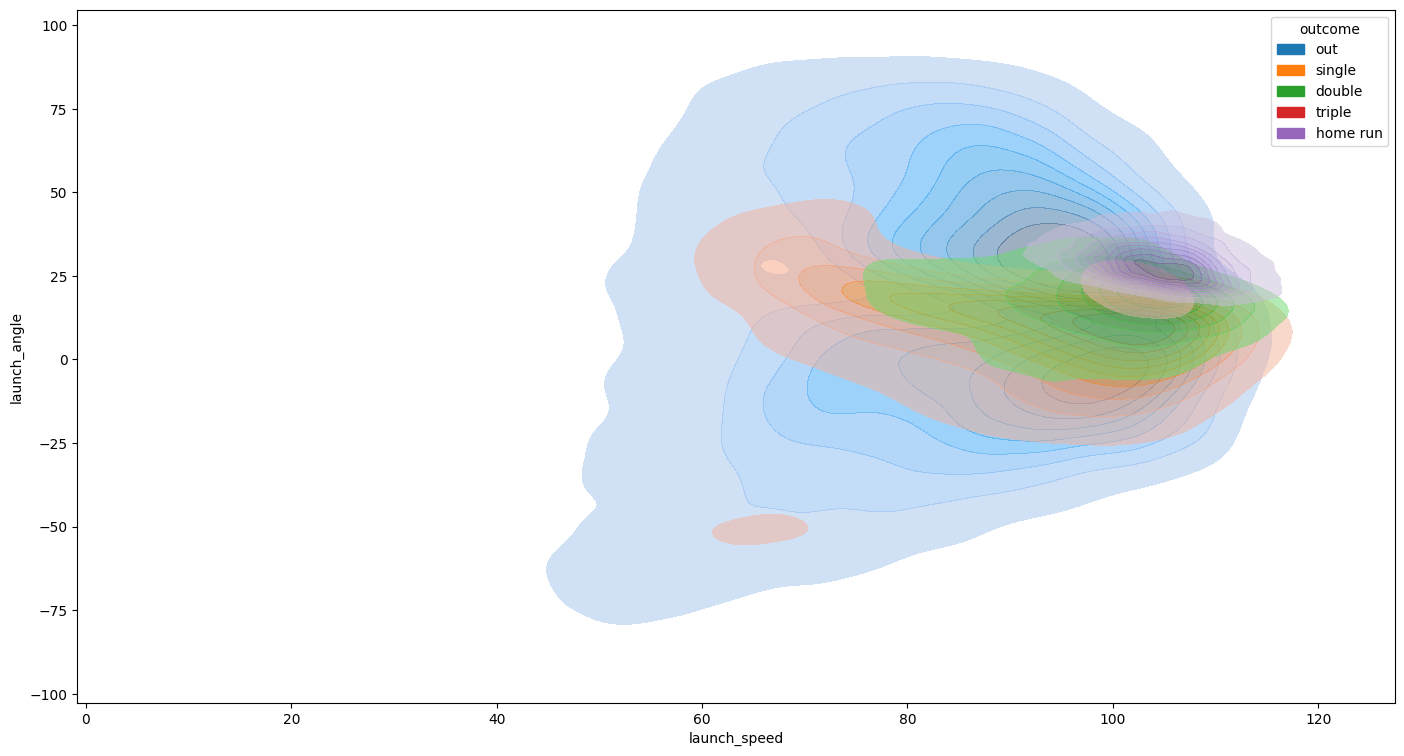

In [11]:
fig = plt.figure(figsize=(17, 9))
sns.kdeplot(
    data=df,
    x="launch_speed",
    y="launch_angle",
    hue="outcome",
    fill=True,
    alpha=0.5,
)
fig.savefig("plots/outcomes_kde.png", dpi=300, bbox_inches="tight")

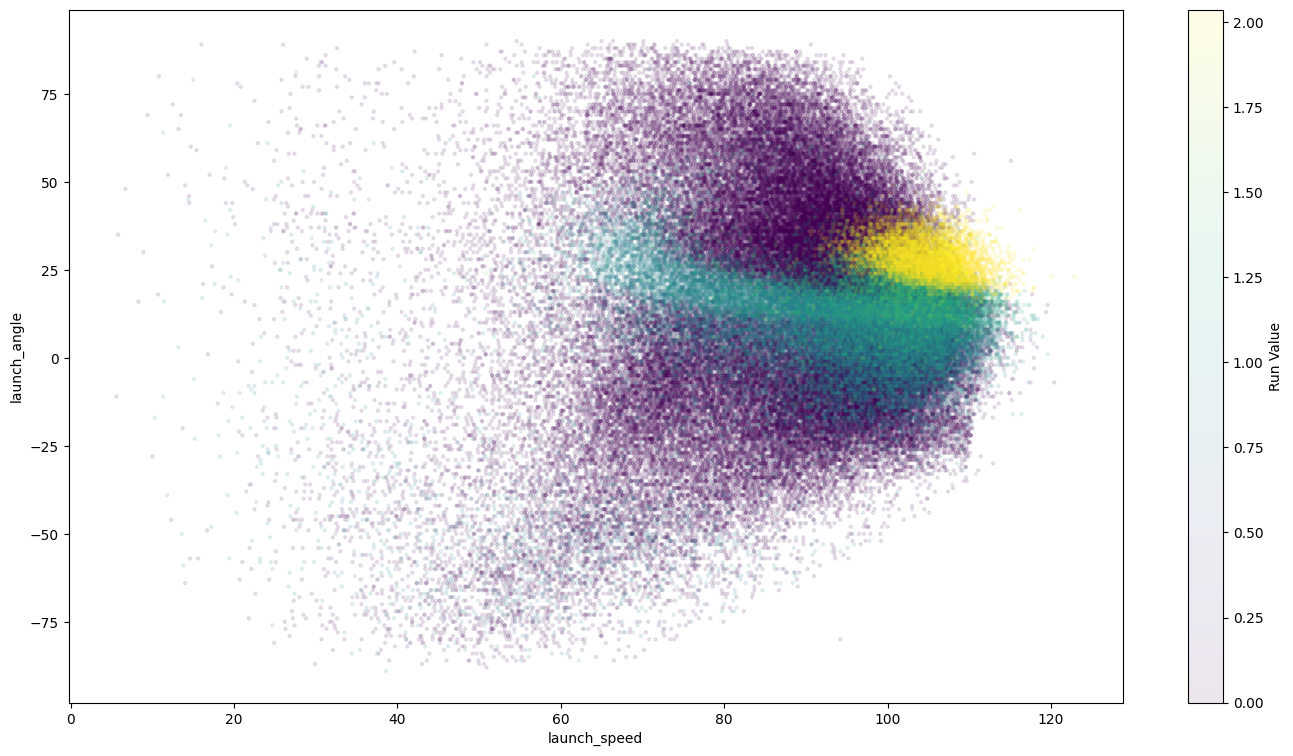

In [12]:
fig = plt.figure(figsize=(17, 9))

sc = plt.scatter(
    df["launch_speed"],
    df["launch_angle"],
    c=df["run_value"],
    cmap="viridis",
    alpha=0.1,
    s=5,
)

plt.colorbar(sc, label="Run Value")
plt.xlabel("launch_speed")
plt.ylabel("launch_angle")
fig.savefig("plots/run_value.png", dpi=300, bbox_inches="tight")

In [13]:
# import plotly.express as px

# fig = px.scatter(
#     df.sample(20_000),  # sample down — browser can't handle 100k pts
#     x="launch_speed",
#     y="launch_angle",
#     color="outcome",
#     opacity=0.3,
#     render_mode="webgl",  # critical for performance
# )
# fig.show()

## Models


In [14]:
df

,outcome,launch_speed,launch_angle,run_value
0,out,88.3,70.0,0.000
1,out,84.3,68.0,0.000
2,out,68.6,-8.0,0.000
3,out,97.4,31.0,0.000
4,out,66.2,19.0,0.000
...,...,...,...,...
126245,home run,101.7,27.0,2.037
126246,home run,95.3,33.0,2.037
126247,home run,99.7,29.0,2.037
126248,home run,105.2,24.0,2.037


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.base import BaseEstimator, TransformerMixin

np.random.seed(42)

X = df[["launch_speed", "launch_angle"]]
y = df["outcome"]

rank = {"out": 0, "single": 1, "double": 2, "triple": 3, "home run": 4}

y = y.map(rank).values
le = LabelEncoder()
le.classes_ = np.array(
    sorted(rank, key=rank.get)  # type: ignore
)  # ["out", "single", "double", "triple", "home_run"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


class ClipEV(BaseEstimator, TransformerMixin):
    def __init__(self, max_ev=112, ev_col="launch_speed", ev_index=0):
        self.max_ev = max_ev
        self.ev_col = ev_col
        self.ev_index = ev_index

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        if isinstance(X, list):
        if isinstance(X, pd.DataFrame):
            X = X.copy()
            if self.ev_col not in X.columns:
                raise ValueError(f"Column '{self.ev_col}' not found in DataFrame")
            X[self.ev_col] = X[self.ev_col].clip(upper=self.max_ev)
            return X
        elif isinstance(X, np.ndarray):
            X = X.copy()
            X[:, self.ev_index] = np.clip(X[:, self.ev_index], None, self.max_ev)
            return X

        else:
            raise TypeError(f"Unsupported type: {type(X)}")


knn = Pipeline(
    [
        ("clip_ev", ClipEV()),
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=750)),
    ]
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Log Loss:", log_loss(y_test, knn.predict_proba(X_test)))
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.7721980198019802
Log Loss: 0.5713074502759637

Classification report:

              precision    recall  f1-score   support

         out       0.82      0.91      0.86     17077
      single       0.63      0.56      0.59      5313
      double       0.46      0.10      0.16      1581
      triple       0.00      0.00      0.00       128
    home run       0.69      0.67      0.68      1151

    accuracy                           0.77     25250
   macro avg       0.52      0.45      0.46     25250
weighted avg       0.75      0.77      0.75     25250



In [16]:
def make_prediction(ev, la, model):
    np.set_printoptions(suppress=True, precision=4)
    predicted = le.inverse_transform(model.predict([[ev, la]]))[0]
    probs = model.predict_proba([[ev, la]])
    values = {
        "out": 0,
        "single": 0.881,
        "double": 1.257,
        "triple": 1.593,
        "home run": 2.058,
    }
    value_array = np.array([values[c] for c in le.classes_])
    exp_val = probs @ value_array
    print("prediction:", predicted)
    print(dict(zip(le.classes_, *probs.round(3))))
    print(f"Expected run value: {round(exp_val[0], 3)}")


make_prediction(115, 27, knn)

prediction: home run
{'out': 0.029, 'single': 0.011, 'double': 0.051, 'triple': 0.008, 'home run': 0.901}
Expected run value: 1.941


In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    log_loss,
    brier_score_loss,
    roc_auc_score,
)

RANK = {"out": 0, "single": 1, "double": 2, "triple": 3, "home run": 4}
CLASS_NAMES = sorted(RANK, key=RANK.get)
N_CLASSES = len(RANK)


class AdaptiveKNNClassifier(BaseEstimator, ClassifierMixin):

    def __init__(
        self, k_smooth=750, k_sharp=50, confidence_power=2.0, algorithm="kd_tree"
    ):
        self.k_smooth = k_smooth
        self.k_sharp = k_sharp
        self.confidence_power = confidence_power
        self.algorithm = algorithm

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.n_classes_ = len(self.classes_)

        self.smooth_ = Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "knn",
                    KNeighborsClassifier(
                        n_neighbors=self.k_smooth, algorithm=self.algorithm
                    ),
                ),
            ]
        )
        self.sharp_ = Pipeline(
            [
                ("clip_ev", ClipEV(max_ev=112)),
                ("scaler", StandardScaler()),
                (
                    "knn",
                    KNeighborsClassifier(
                        n_neighbors=self.k_sharp,
                        algorithm=self.algorithm,
                    ),
                ),
            ]
        )

        self.smooth_.fit(X, y)
        self.sharp_.fit(X, y)
        self.is_fitted_ = True
        return self

    def predict_proba(self, X):
        check_is_fitted(self)

        probs_smooth = self.smooth_.predict_proba(X)  
        probs_sharp = self.sharp_.predict_proba(X) 

        confidence = probs_sharp.max(axis=1) 
        alpha = ((confidence - 0.5) / 0.5).clip(0, 1) ** self.confidence_power
        alpha = alpha[:, np.newaxis]  

        blended = (1 - alpha) * probs_smooth + alpha * probs_sharp
        return blended

    def predict(self, X):
        check_is_fitted(self)
        return self.classes_[self.predict_proba(X).argmax(axis=1)]


X = df[["launch_speed", "launch_angle"]]
y = df["outcome"].map(RANK).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

adaptive_knn = AdaptiveKNNClassifier(k_smooth=1000, k_sharp=150, confidence_power=1.0)
adaptive_knn.fit(X_train, y_train)

y_pred = adaptive_knn.predict(X_test)
y_prob = adaptive_knn.predict_proba(X_test)

print("=" * 60)
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Log-loss : {log_loss(y_test, y_prob, labels=list(range(N_CLASSES))):.4f}")

auc_scores = roc_auc_score(y_test, y_prob, multi_class="ovr", average=None)
for cls, auc in zip(CLASS_NAMES, auc_scores):
    print(f"  AUC ({cls:<9}): {auc:.4f}")
print(f"\nMean AUC (OvR) : {auc_scores.mean():.4f}")

for i, cls in enumerate(CLASS_NAMES):
    bs = brier_score_loss((y_test == i).astype(int), y_prob[:, i])
    print(f"  Brier ({cls:<9}): {bs:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_logloss = []
for train_idx, val_idx in cv.split(X, y):
    fold = AdaptiveKNNClassifier(k_smooth=750, k_sharp=50, confidence_power=2.0)
    fold.fit(X.iloc[train_idx], y[train_idx])
    fold_prob = fold.predict_proba(X.iloc[val_idx])
    cv_logloss.append(log_loss(y[val_idx], fold_prob, labels=list(range(N_CLASSES))))

cv_logloss = np.array(cv_logloss)
print(f"5-fold CV log-loss: {cv_logloss.mean():.4f} +/- {cv_logloss.std():.4f}")


def predict_outcome(launch_speed, launch_angle):
    X_new = pd.DataFrame(
        [[launch_speed, launch_angle]], columns=["launch_speed", "launch_angle"]
    )
    probs = adaptive_knn.predict_proba(X_new)[0]
    return {cls: round(float(p), 4) for cls, p in zip(CLASS_NAMES, probs)}


example = predict_outcome(launch_speed=105, launch_angle=28)
print("\nExample prediction (105 mph, 28 degrees):")
for outcome, prob in example.items():
    bar = "#" * int(prob * 40)
    print(f"  {outcome:<10} {prob:.2%}  {bar}")

Accuracy : 0.7722
Log-loss : 0.5805
  AUC (out      ): 0.8706
  AUC (single   ): 0.8790
  AUC (double   ): 0.8369
  AUC (triple   ): 0.8182
  AUC (home run ): 0.9854

Mean AUC (OvR) : 0.8780
  Brier (out      ): 0.1331
  Brier (single   ): 0.1088
  Brier (double   ): 0.0512
  Brier (triple   ): 0.0050
  Brier (home run ): 0.0193

Classification report:

              precision    recall  f1-score   support

         out       0.82      0.92      0.86     17077
      single       0.63      0.56      0.59      5313
      double       0.45      0.09      0.15      1581
      triple       0.00      0.00      0.00       128
    home run       0.69      0.67      0.68      1151

    accuracy                           0.77     25250
   macro avg       0.52      0.45      0.46     25250
weighted avg       0.74      0.77      0.75     25250

5-fold CV log-loss: 0.6171 +/- 0.0056

Example prediction (105 mph, 28 degrees):
  out        16.81%  ######
  single     0.58%  
  double     6.35%  ##
  

In [18]:
make_prediction(115, 27, adaptive_knn)

prediction: home run
{'out': 0.001, 'single': 0.0, 'double': 0.002, 'triple': 0.007, 'home run': 0.99}
Expected run value: 2.051


In [19]:
model = adaptive_knn
X_test = X_test.reset_index(drop=True)
preds = pd.DataFrame(model.predict_proba(X_test), columns=le.classes_)
full_test_preds = X_test.join(preds)
full_test_preds

,launch_speed,launch_angle,out,single,double,triple,home run
0,103.2,-6.0,0.662116,0.317884,0.017920,0.002080,0.000000
1,103.5,-4.0,0.642880,0.331360,0.020800,0.004960,0.000000
2,96.3,27.0,0.774996,0.008178,0.102249,0.009991,0.104587
3,80.7,25.0,0.645262,0.271804,0.076658,0.006276,0.000000
4,73.0,-3.0,0.912756,0.046760,0.040484,0.000000,0.000000
...,...,...,...,...,...,...,...
25245,108.8,12.0,0.180933,0.510280,0.286720,0.022067,0.000000
25246,76.2,52.0,0.943822,0.035644,0.020533,0.000000,0.000000
25247,48.3,-65.0,0.792280,0.207720,0.000000,0.000000,0.000000
25248,106.5,8.0,0.265973,0.621582,0.108578,0.003867,0.000000


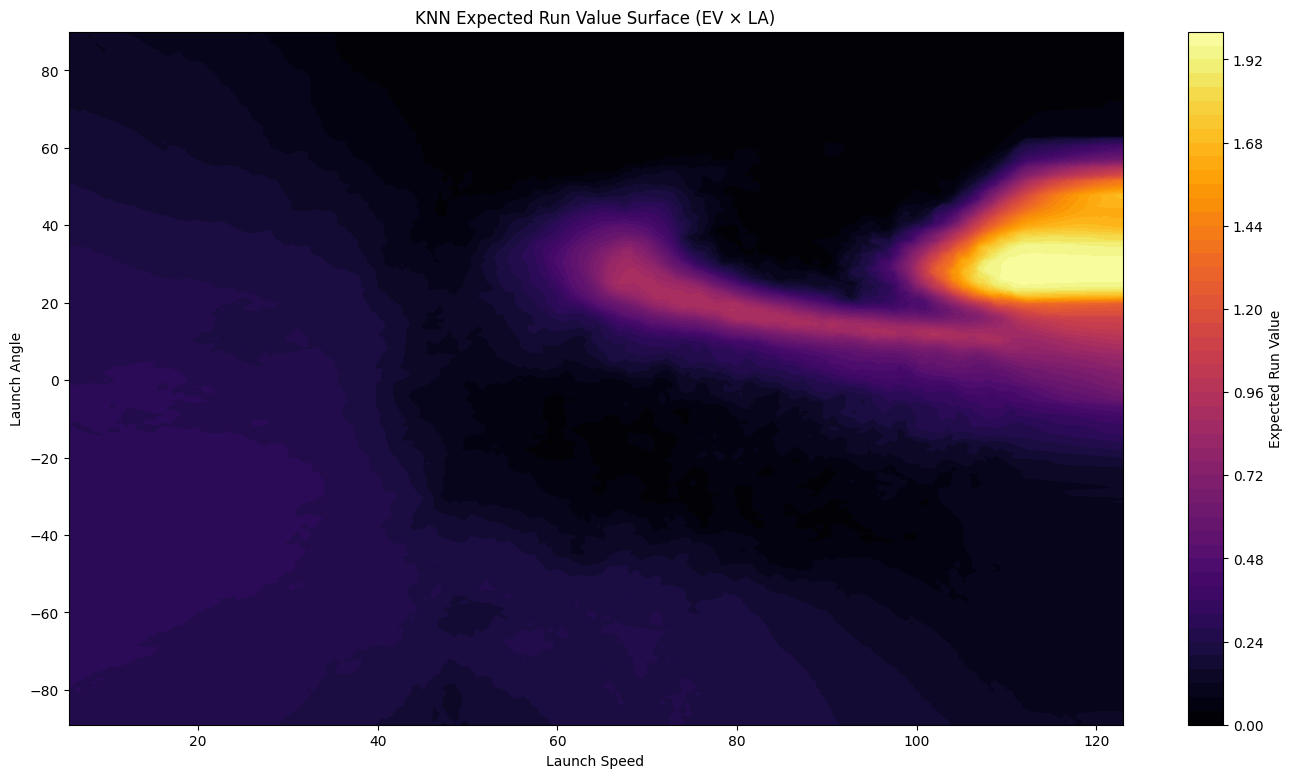

In [ ]:
ev_range = np.linspace(df["launch_speed"].min(), df["launch_speed"].max(), 200)
la_range = np.linspace(df["launch_angle"].min(), df["launch_angle"].max(), 200)

ev_grid, la_grid = np.meshgrid(ev_range, la_range)
grid_points = np.c_[ev_grid.ravel(), la_grid.ravel()]
probs = model.predict_proba(grid_points)
values = {"out": 0.0, "single": 0.9, "double": 1.3, "triple": 1.6, "home run": 2.0}

value_array = np.array([values[c] for c in le.classes_])
run_values = probs @ value_array
run_surface = run_values.reshape(ev_grid.shape)
plt.figure(figsize=(17, 9))


contour = plt.contourf(ev_grid, la_grid, run_surface, levels=50, cmap="inferno")
plt.colorbar(contour, label="Expected Run Value")

plt.xlabel("Launch Speed")
plt.ylabel("Launch Angle")
plt.title("KNN Expected Run Value Surface (EV × LA)")

plt.show()

In [21]:
ev_range = np.linspace(df["launch_speed"].min(), df["launch_speed"].max(), 200)
la_range = np.linspace(df["launch_angle"].min(), df["launch_angle"].max(), 200)

ev_grid, la_grid = np.meshgrid(ev_range, la_range)
grid_points = np.c_[ev_grid.ravel(), la_grid.ravel()]

probs = model.predict_proba(grid_points)
hr_probs = probs[:, -1].reshape(ev_grid.shape)

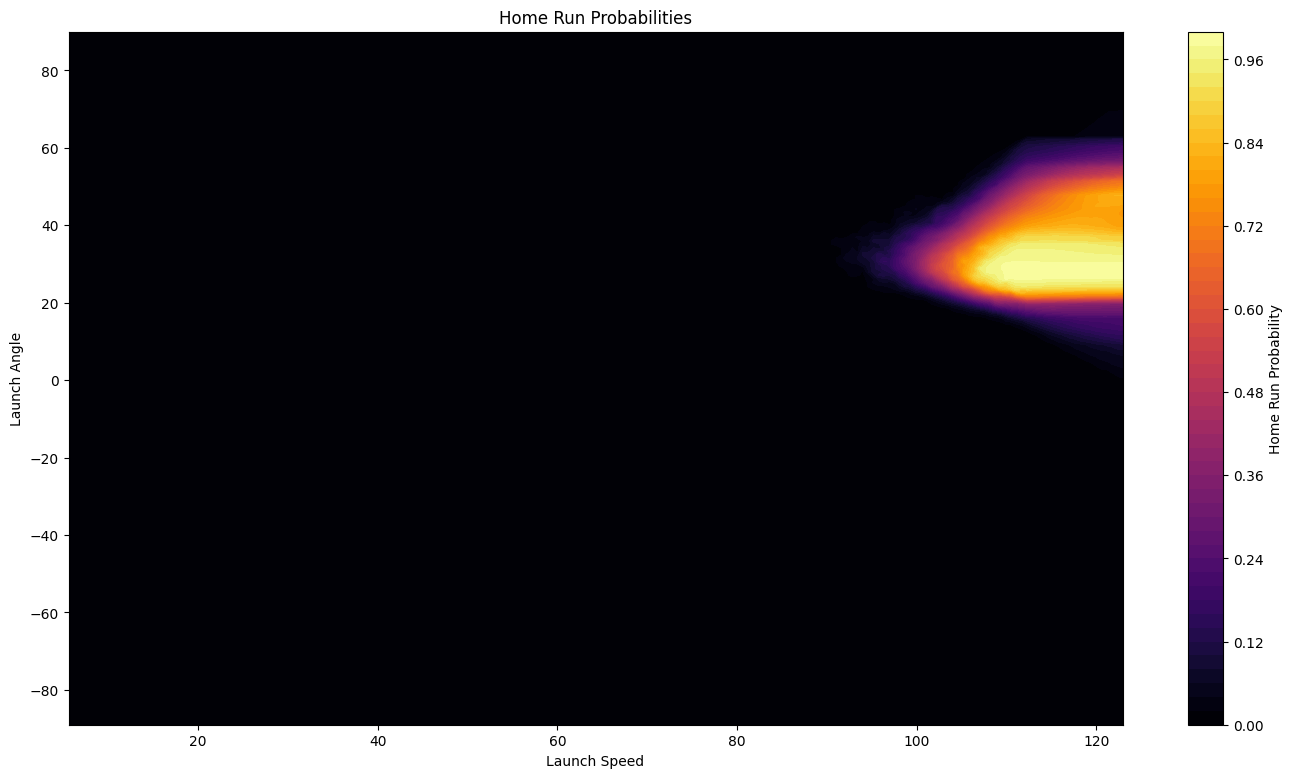

In [22]:
plt.figure(figsize=(17, 9))

contour = plt.contourf(
    ev_grid, la_grid, hr_probs, levels=50, cmap="inferno"  # , norm=PowerNorm(gamma=0.5)
)
plt.colorbar(contour, label="Home Run Probability")

plt.xlabel("Launch Speed")
plt.ylabel("Launch Angle")
plt.title("Home Run Probabilities")

plt.show()

## xwOBA


In [23]:
full_df = full_df.rename(columns={"events": "outcome"})
woba_df = full_df.rename(columns={"events": "outcome"})[
    (full_df["outcome"].notna())
    & (
        (full_df["type"] == "S")
        | (full_df["type"] == "B")
        | (
            (full_df["type"] == "X")
            & (full_df["launch_angle"].notna())
            & (full_df["launch_speed"].notna())
        )
    )
][["batter", "pitcher", "outcome", "launch_speed", "launch_angle"]].reset_index(
    drop=True
)

event_map = {
    # outs
    "out": "out",
    "field_out": "out",
    "force_out": "out",
    "grounded_into_double_play": "out",
    "double_play": "out",
    "triple_play": "out",
    "strikeout": "out",
    "strikeout_double_play": "out",
    "field_error": "out",
    "fielders_choice_out": "out",
    "fielders_choice": "out",
    # singles
    "single": "single",
    # doubles
    "double": "double",
    # triples
    "triple": "triple",
    # home runs
    "home_run": "home run",
    # walks
    "walk": "ubb",  # unintentional BB (most datasets don't separate intent)
    "catcher_interf": "ubb",
    "intent_walk": "ibb",
    # hit by pitch
    "hit_by_pitch": "hbp",
    # sacrifice fly
    "sac_fly": "sf",
    "sacrifice_fly": "sf",
    "sac_fly_double_play": "sf",
    "sac_bunt": None,  # drop
    "truncated_pa": None,  # drop
}
woba_df["type"] = woba_df["outcome"].map(event_map)
woba_df = woba_df.dropna(subset="type")

unique_ids = woba_df["batter"].unique()
lookup = playerid_reverse_lookup(unique_ids)
lookup["full_name"] = lookup["name_first"] + " " + lookup["name_last"]
id_map = dict(zip(lookup["key_mlbam"], lookup["full_name"]))
woba_df["batter_name"] = woba_df["batter"].map(id_map)
woba_df

Gathering player lookup table. This may take a moment.


,batter,pitcher,outcome,launch_speed,launch_angle,type,batter_name
0,664702,676012,strikeout,NaN,NaN,out,myles straw
1,680718,676012,walk,NaN,NaN,ubb,addison barger
2,645305,676012,strikeout,NaN,NaN,out,ali sánchez
3,656811,666151,strikeout,NaN,NaN,out,ryan o'hearn
4,694388,669211,strikeout,NaN,NaN,out,joey loperfido
...,...,...,...,...,...,...,...
187198,660821,691951,strikeout,NaN,NaN,out,jesús sánchez
187199,673237,691951,single,100.8,1.0,single,yainer diaz
187200,605170,691951,hit_by_pitch,NaN,NaN,hbp,víctor caratini
187201,643289,691951,single,77.1,13.0,single,mauricio dubón


In [24]:
mask = woba_df[["launch_speed", "launch_angle"]].notna().all(axis=1)

probs = model.predict_proba(woba_df.loc[mask, ["launch_speed", "launch_angle"]])

classes = le.classes_

prob_df = pd.DataFrame(
    probs, columns=[f"p_{c}" for c in classes], index=woba_df.loc[mask].index
)

woba_df = woba_df.join(prob_df)
woba_df

,batter,pitcher,outcome,launch_speed,launch_angle,type,batter_name,p_out,p_single,p_double,p_triple,p_home run
0,664702,676012,strikeout,NaN,NaN,out,myles straw,NaN,NaN,NaN,NaN,NaN
1,680718,676012,walk,NaN,NaN,ubb,addison barger,NaN,NaN,NaN,NaN,NaN
2,645305,676012,strikeout,NaN,NaN,out,ali sánchez,NaN,NaN,NaN,NaN,NaN
3,656811,666151,strikeout,NaN,NaN,out,ryan o'hearn,NaN,NaN,NaN,NaN,NaN
4,694388,669211,strikeout,NaN,NaN,out,joey loperfido,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
187198,660821,691951,strikeout,NaN,NaN,out,jesús sánchez,NaN,NaN,NaN,NaN,NaN
187199,673237,691951,single,100.8,1.0,single,yainer diaz,0.529000,0.420000,0.05100,0.000000,0.0
187200,605170,691951,hit_by_pitch,NaN,NaN,hbp,víctor caratini,NaN,NaN,NaN,NaN,NaN
187201,643289,691951,single,77.1,13.0,single,mauricio dubón,0.445422,0.515484,0.03728,0.001813,0.0


In [25]:
run_values = {
    "out": 0,
    "ubb": 0.69,
    "hbp": 0.722,
    "single": 0.881,
    "double": 1.257,
    "triple": 1.593,
    "home run": 2.058,
}

woba_df["ev_actual"] = woba_df["type"].map(run_values)

woba_df["ev_pred"] = (
    woba_df["p_out"] * run_values["out"]
    + woba_df["p_single"] * run_values["single"]
    + woba_df["p_double"] * run_values["double"]
    + woba_df["p_triple"] * run_values["triple"]
    + woba_df["p_home run"] * run_values["home run"]
)

woba_df["ev_pred"] = woba_df["ev_pred"].fillna(woba_df["ev_actual"])

woba_df["exp_val"] = woba_df["ev_pred"].where(
    woba_df["p_out"].notna(), woba_df["ev_actual"]
)
woba_df = woba_df.drop(columns=["ev_actual", "ev_pred"])
woba_df

,batter,pitcher,outcome,launch_speed,launch_angle,type,batter_name,p_out,p_single,p_double,p_triple,p_home run,exp_val
0,664702,676012,strikeout,NaN,NaN,out,myles straw,NaN,NaN,NaN,NaN,NaN,0.000000
1,680718,676012,walk,NaN,NaN,ubb,addison barger,NaN,NaN,NaN,NaN,NaN,0.690000
2,645305,676012,strikeout,NaN,NaN,out,ali sánchez,NaN,NaN,NaN,NaN,NaN,0.000000
3,656811,666151,strikeout,NaN,NaN,out,ryan o'hearn,NaN,NaN,NaN,NaN,NaN,0.000000
4,694388,669211,strikeout,NaN,NaN,out,joey loperfido,NaN,NaN,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187198,660821,691951,strikeout,NaN,NaN,out,jesús sánchez,NaN,NaN,NaN,NaN,NaN,0.000000
187199,673237,691951,single,100.8,1.0,single,yainer diaz,0.529000,0.420000,0.05100,0.000000,0.0,0.434127
187200,605170,691951,hit_by_pitch,NaN,NaN,hbp,víctor caratini,NaN,NaN,NaN,NaN,NaN,0.722000
187201,643289,691951,single,77.1,13.0,single,mauricio dubón,0.445422,0.515484,0.03728,0.001813,0.0,0.503891


In [26]:
grouped = (
    woba_df.groupby(["batter", "batter_name"])
    .agg(xwOBA=("exp_val", "mean"), pa=("exp_val", "count"))
    .sort_values(by="xwOBA")
    .reset_index()
)
grouped = grouped[grouped["pa"] >= 200].reset_index(drop=True)[
    ["batter_name", "pa", "xwOBA"]
]

grouped["percentile"] = grouped["xwOBA"].rank(pct=True) * 100
grouped["z_score"] = (grouped["xwOBA"] - grouped["xwOBA"].mean()) / grouped[
    "xwOBA"
].std()
grouped = grouped.round(3)
grouped

,batter_name,pa,xwOBA,percentile,z_score
0,tyler fitzgerald,251,0.231,0.287,-2.436
1,trey sweeney,332,0.240,0.573,-2.182
2,kameron misner,216,0.241,0.860,-2.141
3,ezequiel duran,228,0.242,1.146,-2.114
4,nick allen,414,0.243,1.433,-2.084
...,...,...,...,...,...
344,corey seager,445,0.407,98.854,2.630
345,kyle schwarber,729,0.411,99.140,2.748
346,shohei ohtani,705,0.428,99.427,3.216
347,juan soto,706,0.429,99.713,3.266


In [41]:
full_df.groupby("batter")["estimated_woba_using_speedangle"].agg(
    ("mean", "count")
).sort_values(by="mean").dropna().reset_index().loc[lambda x: x["count"] >= 200].assign(
    name=lambda x: x["batter"].map(id_map)
).round(
    3
)

,batter,mean,count,name
102,606115,0.238,209,orlando arcia
113,666149,0.242,237,tyler fitzgerald
122,700242,0.245,324,trey sweeney
126,670224,0.247,216,kameron misner
129,690022,0.248,203,ryan ritter
...,...,...,...,...
663,656941,0.403,713,kyle schwarber
664,543807,0.404,571,george springer
666,660271,0.420,699,shohei ohtani
668,665742,0.429,695,juan soto


In [ ]:
grouped.to_csv("player_xwOBA_2025.csv", index=False)

In [42]:
make_prediction(66.8, 27, knn)

prediction: single
{'out': 0.131, 'single': 0.835, 'double': 0.035, 'triple': 0.0, 'home run': 0.0}
Expected run value: 0.779
